In [19]:
import torchvision
import torch
import torchvision.datasets as dataset
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

from PIL import Image   

## Dataset

### (Optional) Counting the Mean and STD for the pixel in the dataset

In [16]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch

# Temporary transform: convert to tensor only
temp_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# Apply same temp_transform to target to ensure it's a Tensor too
temp_target_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.PILToTensor()
])

# Load dataset
dataset = datasets.OxfordIIITPet(root='./data',
                                  split='trainval',
                                  transform=temp_transform,
                                  target_transform=temp_target_transform,
                                  target_types='segmentation',
                                  download=True)

loader = DataLoader(dataset, batch_size=16, shuffle=False)

mean = 0.
std = 0.
nb_samples = 0.

for data, _ in loader:
    batch_samples = data.size(0)
    data = data.view(batch_samples, data.size(1), -1)  # Flatten HxW
    mean += data.mean(2).sum(0)
    std += data.std(2).sum(0)
    nb_samples += batch_samples

mean /= nb_samples
std /= nb_samples

print(f"Dataset Mean: {mean}")
print(f"Dataset Std: {std}")


Dataset Mean: tensor([0.4783, 0.4459, 0.3957])
Dataset Std: tensor([0.2261, 0.2230, 0.2247])


### Load Dataset

First, we create a transform to augment the dataset that we will receive.

In [37]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])           # Mean and STD from ImageNet
    transforms.Normalize(mean=[0.4783, 0.4459, 0.3957], std=[0.2261, 0.223, 0.2247])        # Mean and STD from our current dataset
])

target_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.PILToTensor()
])

`transform` is intended for the image dataset, this includes all the preprocessing step for the input image.

`target_transform` is applied for the mask ground truth, so it has to maintain the original data.

Now, we can load the OxfordIIITPet dataset from torchvision.

In [38]:
# Load the training set
train_dataset = dataset.OxfordIIITPet(root='./data',
                                       split='trainval',
                                       transform=transform,
                                       target_transform=target_transform,
                                       target_types='segmentation',
                                       download=True)

# Load the testing set
test_dataset = dataset.OxfordIIITPet(root='./data',
                                      split='test',
                                      transform=transform,
                                      target_transform=target_transform,
                                      download=True)

### Create Dataloader

In [39]:
from torch.utils.data import DataLoader, random_split

train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=False)

In [40]:
print(len(train_dataloader))
# print(len(val_loader))
print(len(test_dataloader))

920
918


In [41]:
# Define your split ratio
val_split_ratio = 0.2  # 20% for validation
train_size = int((1 - val_split_ratio) * len(train_dataset))
val_size = len(train_dataset) - train_size

# Randomly split the dataset
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

/tmp/ipykernel_60399/3779747855.py:27: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  mask_np = np.array(mask)


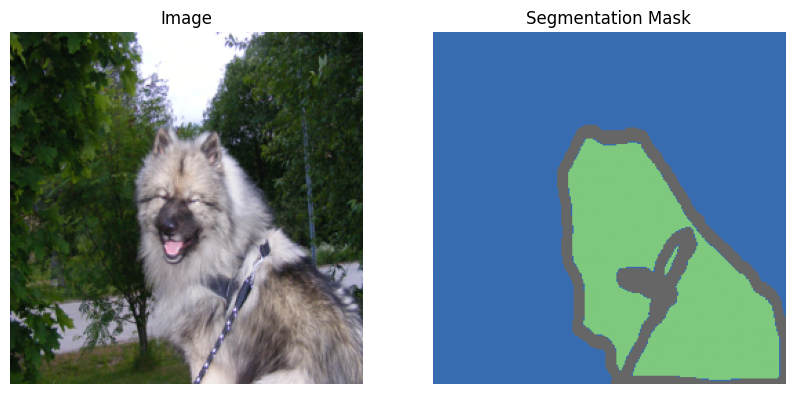

In [49]:
import numpy as np

image, mask = train_dataset[0]  # Returns (PIL.Image or Tensor, mask)



# If image is a tensor, convert it to numpy
# if isinstance(image, torch.Tensor):
image_np = image.permute(1, 2, 0).numpy()  # C x H x W → H x W x C
# else:
    # image_np = np.array(image)


# Unnormalize image for display
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

image_np = image.permute(1, 2, 0).numpy()
image_np = (image_np * std) + mean
image_np = np.clip(image_np, 0, 1)


# Convert mask to numpy
# if isinstance(mask, torch.Tensor):
#     mask_np = mask.numpy()
# else:
mask_np = np.array(mask)

# Plot image and mask side by side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_np)
plt.title('Image')
plt.axis('off')

plt.subplot(1, 2, 2)
# plt.imshow(mask_np, cmap='gray')
plt.imshow(mask_np.squeeze(), cmap='Accent')  # squeeze removes the first dimension

plt.title('Segmentation Mask')
plt.axis('off')

plt.show()
